# Release benchmark: single-coarsener scaling

This notebook measures the public `fit`, `transform`, and full `decode` calls for
all three schema-1 coarseners over increasing tree sizes. It uses two controlled
families:

- **near-binary:** a breadth-first binary tree;
- **near-star:** one high-degree root with short repeated branches.

Every timed row must first pass an exact raw round trip and an input-nonmutation
check. Graph generation and correctness signatures are outside the timed
regions. `fit_transform` is not timed separately because it is the same public
`fit` + `transform` path and would duplicate the primary measurements.


## 0. Imports and repository checkout

Run this notebook from anywhere inside the repository. The environment record
and Git commit are saved with the results.


In [1]:
from __future__ import annotations

import gc
import json
import os
import random
import sys
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import pandas as pd


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "tree_coarsening").is_dir():
            return candidate
    raise RuntimeError("Could not locate the tree-coarsening repository root.")


ROOT = find_project_root(Path.cwd())
BENCHMARK_DIR = ROOT / "benchmarks"

for entry in (str(ROOT), str(BENCHMARK_DIR)):
    if entry not in sys.path:
        sys.path.insert(0, entry)

from benchmark_common import (  # noqa: E402
    environment_metadata,
    make_benchmark_tree,
    make_coarsener,
    method_display_name,
    numba_is_available,
    raw_signature,
    warm_numba_backend,
)

ENVIRONMENT = environment_metadata(ROOT)
ENVIRONMENT

{'python': '3.13.13',
 'python_implementation': 'CPython',
 'python_executable': '<PYTHON_EXECUTABLE>',
 'platform': 'Linux-6.17.0-1025-oem-x86_64-with-glibc2.39',
 'processor': 'x86_64',
 'logical_cpu_count': 24,
 'networkx': '3.6.1',
 'tree_coarsening': '0.11.0',
 'git_commit': 'unknown',
 'numpy': '2.4.6',
 'numba': '0.65.1',
 'physical_memory_bytes': 134489358336}

## 1. Controls

The default `standard` profile is intended for a visual pre-release check.
Use `smoke` to verify notebook execution and `extended` for a quiet benchmark
machine. Numba is explicitly warmed before measured rows; its cold-start time
is reported separately.


In [2]:
PROFILES = {
    "smoke": {"sizes": (63, 127), "repeats": 1},
    "standard": {"sizes": (250, 500, 1_000, 2_000, 4_000, 8_000), "repeats": 3},
    "extended": {
        "sizes": (500, 1_000, 2_000, 4_000, 8_000, 16_000, 32_000, 64_000),
        "repeats": 5,
    },
}

PROFILE = os.environ.get("TREE_COARSENING_BENCH_PROFILE", "standard")
if PROFILE not in PROFILES:
    raise ValueError(f"Unknown benchmark profile {PROFILE!r}; choose from {tuple(PROFILES)}")

SIZES = PROFILES[PROFILE]["sizes"]
REPEATS = PROFILES[PROFILE]["repeats"]
SHAPES = ("near_binary", "near_star")
METHODS = ["star", "bpe_python", "bpe_numba", "named"]
if not numba_is_available():
    METHODS.remove("bpe_numba")

VALIDATE = "full"
BPE_NUM_MERGES = 12
BPE_MIN_PAIR_COUNT = 2
SAVE_RESULTS = True
TASK_ORDER_SEED = 20260620

{
    "profile": PROFILE,
    "sizes": SIZES,
    "repeats": REPEATS,
    "shapes": SHAPES,
    "methods": METHODS,
    "validate": VALIDATE,
    "bpe_num_merges": BPE_NUM_MERGES,
}

{'profile': 'extended',
 'sizes': (500, 1000, 2000, 4000, 8000, 16000, 32000, 64000),
 'repeats': 5,
 'shapes': ('near_binary', 'near_star'),
 'methods': ['star', 'bpe_python', 'bpe_numba', 'named'],
 'validate': 'full',
 'bpe_num_merges': 12}

## 2. Build the deterministic corpora

Generation time is recorded but never folded into coarsener time. The same raw
graph object is supplied to every method; nonmutation is checked after every
row.


In [3]:
corpora = {}
generation_rows = []
raw_signatures = {}

for shape in SHAPES:
    for n_nodes in SIZES:
        started = perf_counter()
        graph = make_benchmark_tree(shape, n_nodes, seed=TASK_ORDER_SEED + n_nodes)
        generation_seconds = perf_counter() - started
        key = (shape, n_nodes)
        corpora[key] = graph
        raw_signatures[key] = raw_signature(graph)
        generation_rows.append(
            {
                "shape": shape,
                "n_nodes": graph.number_of_nodes(),
                "n_edges": graph.number_of_edges(),
                "generation_seconds": generation_seconds,
                "root_out_degree": max(dict(graph.out_degree()).values()),
            }
        )

generation_df = pd.DataFrame(generation_rows)
generation_df

,shape,n_nodes,n_edges,generation_seconds,root_out_degree
0,near_binary,500,499,0.005060,2
1,near_binary,1000,999,0.001777,2
2,near_binary,2000,1999,0.002527,2
3,near_binary,4000,3999,0.005042,2
4,near_binary,8000,7999,0.009907,2
5,near_binary,16000,15999,0.019569,2
6,near_binary,32000,31999,0.042287,2
7,near_binary,64000,63999,0.215086,2
8,near_star,500,499,0.001531,125
9,near_star,1000,999,0.000990,250


## 3. Warm-up outside measured rows

This removes import/cache effects for all methods and, most importantly,
separates Numba compilation from warmed BPE fitting.


In [4]:
warmup_graph = make_benchmark_tree("near_binary", 127, seed=1)
warmup_rows = []

for method in [item for item in METHODS if item != "bpe_numba"]:
    model = make_coarsener(
        method,
        model_id=f"single-warmup-{method}",
        bpe_num_merges=2,
        bpe_min_pair_count=1,
    )
    started = perf_counter()
    model.fit([warmup_graph], validate=False)
    encoded = model.transform(warmup_graph, validate=False)
    decoded = model.decode(encoded, validate=False)
    elapsed = perf_counter() - started
    assert raw_signature(decoded) == raw_signature(warmup_graph)
    warmup_rows.append({"method": method, "warmup_seconds": elapsed})

numba_cold_seconds = warm_numba_backend(validate=False) if "bpe_numba" in METHODS else None
if numba_cold_seconds is not None:
    warmup_rows.append({"method": "bpe_numba", "warmup_seconds": numba_cold_seconds})

pd.DataFrame(warmup_rows).assign(method=lambda frame: frame["method"].map(method_display_name))

,method,warmup_seconds
0,Parametric Star,0.005006
1,Edge BPE (Python),0.003963
2,Named Vertex,0.004765
3,Edge BPE (Numba),0.833319


## 4. Timed sweep

Each repetition constructs and fits a fresh coarsener. Task order is shuffled
deterministically to reduce systematic ordering bias. The timed total is the
sum of the three public calls, excluding model construction, graph generation,
and correctness signatures.


In [5]:
tasks = [
    (repeat, shape, n_nodes, method)
    for repeat in range(REPEATS)
    for shape in SHAPES
    for n_nodes in SIZES
    for method in METHODS
]
random.Random(TASK_ORDER_SEED).shuffle(tasks)

rows = []
for task_index, (repeat, shape, n_nodes, method) in enumerate(tasks, start=1):
    graph = corpora[(shape, n_nodes)]
    expected_raw = raw_signatures[(shape, n_nodes)]
    model = make_coarsener(
        method,
        model_id=f"single-{method}-{shape}-{n_nodes}-{repeat}",
        bpe_num_merges=BPE_NUM_MERGES,
        bpe_min_pair_count=BPE_MIN_PAIR_COUNT,
    )

    started = perf_counter()
    model.fit([graph], validate=VALIDATE)
    fit_seconds = perf_counter() - started

    started = perf_counter()
    encoded = model.transform(graph, validate=VALIDATE)
    transform_seconds = perf_counter() - started

    started = perf_counter()
    decoded = model.decode(encoded, validate=VALIDATE)
    decode_seconds = perf_counter() - started

    roundtrip_ok = raw_signature(decoded) == expected_raw
    input_unchanged = raw_signature(graph) == expected_raw
    if not roundtrip_ok or not input_unchanged:
        raise AssertionError(
            f"Correctness failure for method={method}, shape={shape}, n={n_nodes}, "
            f"repeat={repeat}: roundtrip={roundtrip_ok}, unchanged={input_unchanged}"
        )

    rule_count = len(model.encoder_.rules)
    rows.append(
        {
            "repeat": repeat,
            "shape": shape,
            "n_nodes": n_nodes,
            "method": method,
            "method_name": method_display_name(method),
            "fit_seconds": fit_seconds,
            "transform_seconds": transform_seconds,
            "decode_seconds": decode_seconds,
            "total_seconds": fit_seconds + transform_seconds + decode_seconds,
            "encoded_nodes": encoded.number_of_nodes(),
            "compression_ratio": encoded.number_of_nodes() / n_nodes,
            "rule_count": rule_count,
            "backend_used": getattr(model, "backend_used_", None),
            "roundtrip_ok": roundtrip_ok,
            "input_unchanged": input_unchanged,
        }
    )
    if task_index % max(1, len(tasks) // 10) == 0:
        print(f"completed {task_index}/{len(tasks)} rows")
    del model, encoded, decoded
    gc.collect()

results_df = pd.DataFrame(rows).sort_values(["shape", "method", "n_nodes", "repeat"])
results_df.head()

completed 32/320 rows
completed 64/320 rows
completed 96/320 rows
completed 128/320 rows
completed 160/320 rows
completed 192/320 rows
completed 224/320 rows
completed 256/320 rows
completed 288/320 rows
completed 320/320 rows


,repeat,shape,n_nodes,method,method_name,fit_seconds,transform_seconds,decode_seconds,total_seconds,encoded_nodes,compression_ratio,rule_count,backend_used,roundtrip_ok,input_unchanged
45,0,near_binary,500,bpe_numba,Edge BPE (Numba),0.007672,0.006239,0.012677,0.026588,146,0.292,12,numba,True,True
198,1,near_binary,500,bpe_numba,Edge BPE (Numba),0.003025,0.005426,0.011871,0.020322,146,0.292,12,numba,True,True
17,2,near_binary,500,bpe_numba,Edge BPE (Numba),0.003339,0.006195,0.012687,0.022221,146,0.292,12,numba,True,True
194,3,near_binary,500,bpe_numba,Edge BPE (Numba),0.003104,0.005747,0.012334,0.021185,146,0.292,12,numba,True,True
33,4,near_binary,500,bpe_numba,Edge BPE (Numba),0.003569,0.006057,0.012662,0.022288,146,0.292,12,numba,True,True


## 5. Aggregate and verify

The median is the primary estimate. Minimum and maximum values remain in the
summary so noisy points are visible rather than silently discarded.


In [6]:
if not results_df["roundtrip_ok"].all() or not results_df["input_unchanged"].all():
    raise AssertionError("At least one benchmark row failed correctness checks.")

summary_df = (
    results_df.groupby(["shape", "n_nodes", "method", "method_name"], as_index=False)
    .agg(
        fit_median=("fit_seconds", "median"),
        transform_median=("transform_seconds", "median"),
        decode_median=("decode_seconds", "median"),
        total_median=("total_seconds", "median"),
        total_min=("total_seconds", "min"),
        total_max=("total_seconds", "max"),
        encoded_nodes=("encoded_nodes", "median"),
        compression_ratio=("compression_ratio", "median"),
        rule_count=("rule_count", "median"),
    )
    .sort_values(["shape", "method", "n_nodes"])
)

summary_df["nodes_per_total_second"] = summary_df["n_nodes"] / summary_df["total_median"]
summary_df

,shape,n_nodes,method,method_name,fit_median,transform_median,decode_median,total_median,total_min,total_max,encoded_nodes,compression_ratio,rule_count,nodes_per_total_second
0,near_binary,500,bpe_numba,Edge BPE (Numba),0.003339,0.006057,0.012662,0.022221,0.020322,0.026588,146.0,0.292000,12.0,22501.367308
4,near_binary,1000,bpe_numba,Edge BPE (Numba),0.005363,0.010706,0.025058,0.040957,0.040446,0.042897,228.0,0.228000,12.0,24415.841199
8,near_binary,2000,bpe_numba,Edge BPE (Numba),0.009785,0.022041,0.047933,0.079759,0.079081,0.083657,436.0,0.218000,12.0,25075.596616
12,near_binary,4000,bpe_numba,Edge BPE (Numba),0.019607,0.045359,0.098145,0.164756,0.157806,0.168501,1170.0,0.292500,12.0,24278.320247
16,near_binary,8000,bpe_numba,Edge BPE (Numba),0.038260,0.092795,0.205544,0.335690,0.329071,0.353659,1677.0,0.209625,12.0,23831.537755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47,near_star,4000,star,Parametric Star,0.012108,0.126215,0.043443,0.181767,0.178638,0.189009,3001.0,0.750250,1.0,22006.234095
51,near_star,8000,star,Parametric Star,0.024447,0.416442,0.092017,0.532907,0.518110,0.546522,6001.0,0.750125,1.0,15011.995681
55,near_star,16000,star,Parametric Star,0.050452,1.457720,0.188833,1.696284,1.684784,1.742626,12001.0,0.750062,1.0,9432.384031
59,near_star,32000,star,Parametric Star,0.112822,5.745789,0.632030,6.480941,6.395285,6.630651,24001.0,0.750031,1.0,4937.554934


## 6. Total public-call time by shape

Look for smooth scaling, stable method ordering, and abrupt slope changes. The
spread table above is as important as the median line when a machine is noisy.


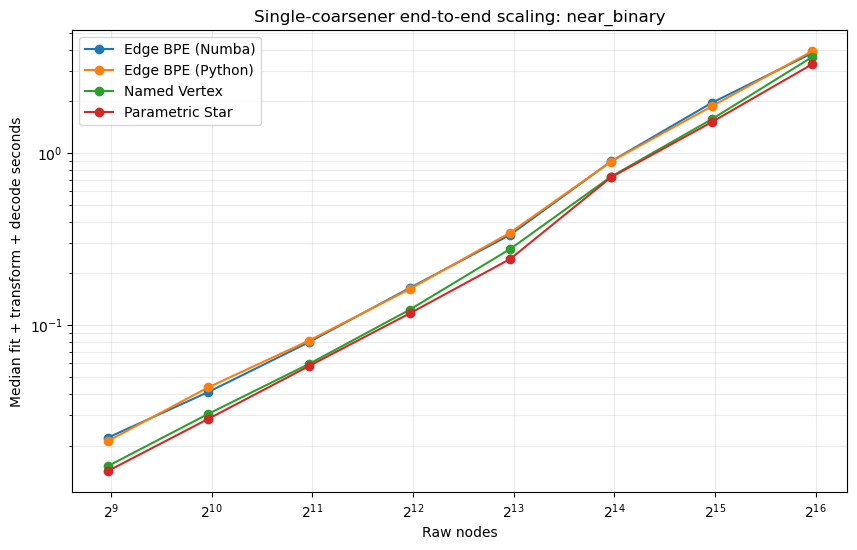

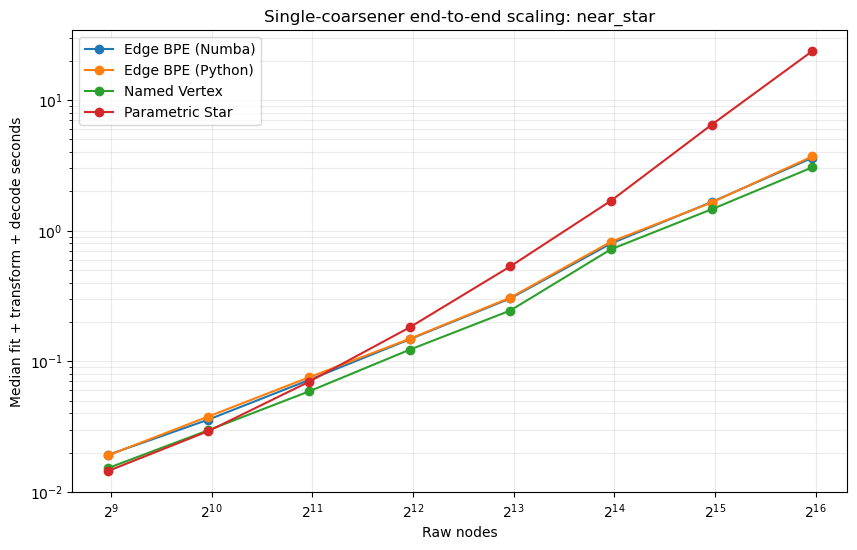

In [7]:
for shape in SHAPES:
    figure = plt.figure(figsize=(10, 6))
    axis = figure.gca()
    subset = summary_df[summary_df["shape"] == shape]
    for method_name, group in subset.groupby("method_name", sort=False):
        group = group.sort_values("n_nodes")
        axis.plot(group["n_nodes"], group["total_median"], marker="o", label=method_name)
    axis.set_xscale("log", base=2)
    axis.set_yscale("log")
    axis.set_xlabel("Raw nodes")
    axis.set_ylabel("Median fit + transform + decode seconds")
    axis.set_title(f"Single-coarsener end-to-end scaling: {shape}")
    axis.grid(True, which="both", alpha=0.25)
    axis.legend()
    plt.show()

## 7. Phase timing and compression

A total-time regression can come from validation/fitting, concrete rewiring, or
exact decoding. Compression ratio and rule count guard against mistaking a
no-op for a speedup.


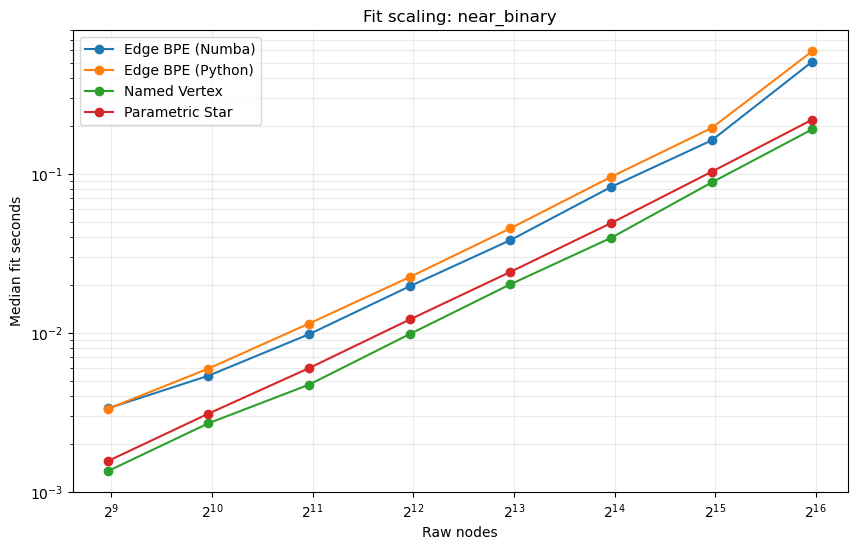

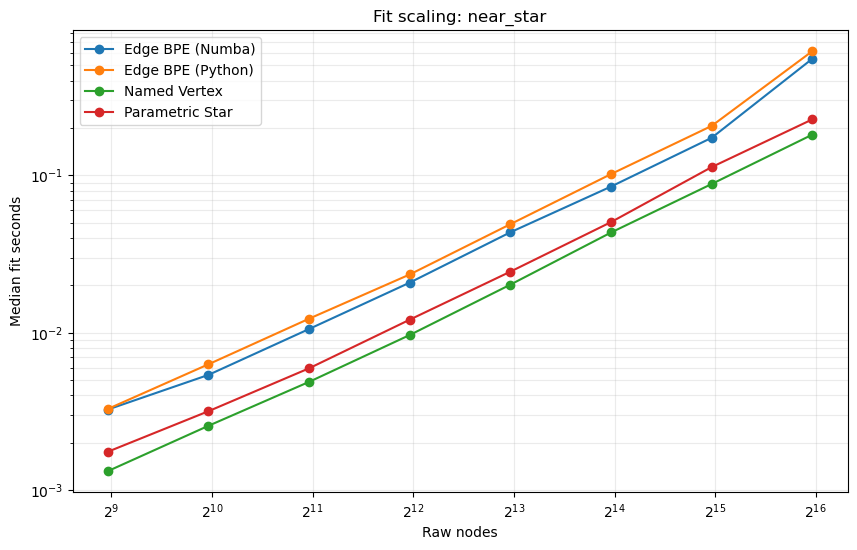

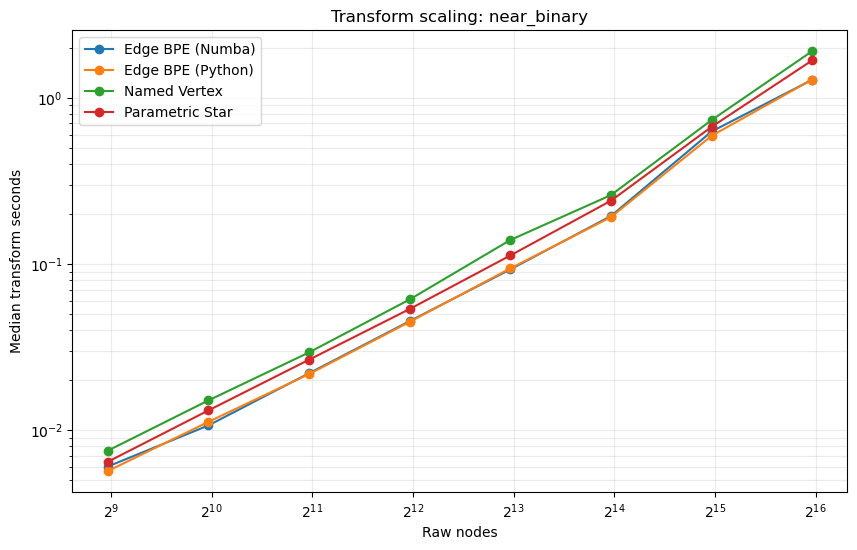

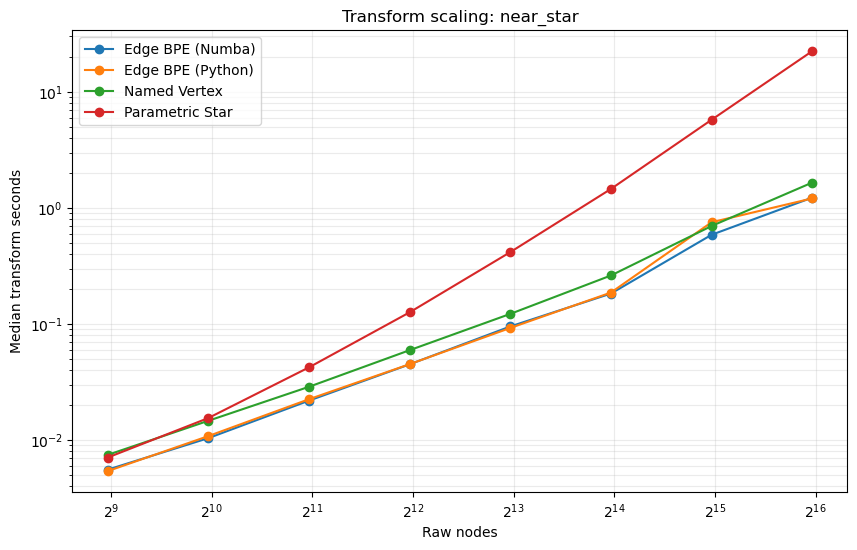

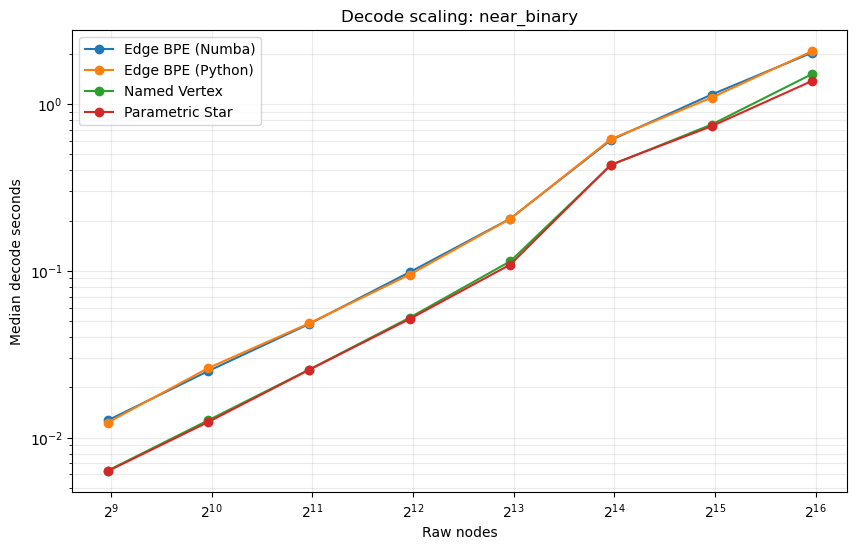

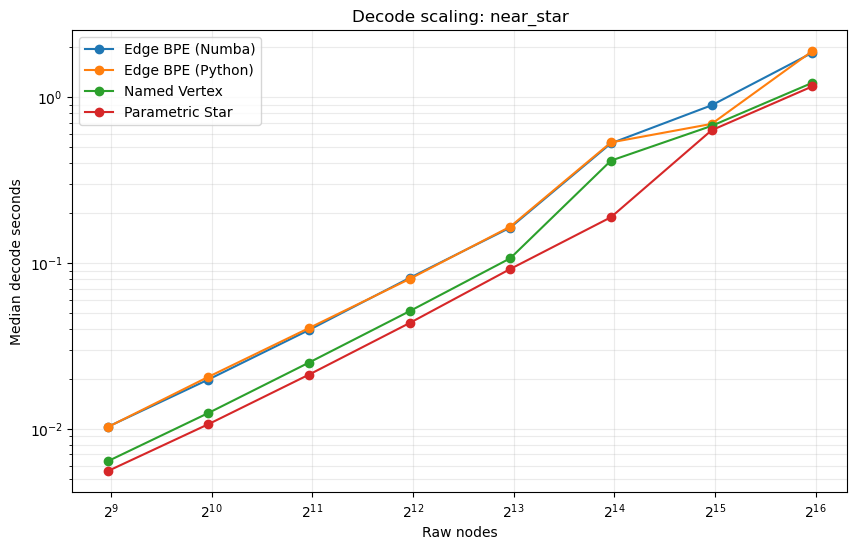

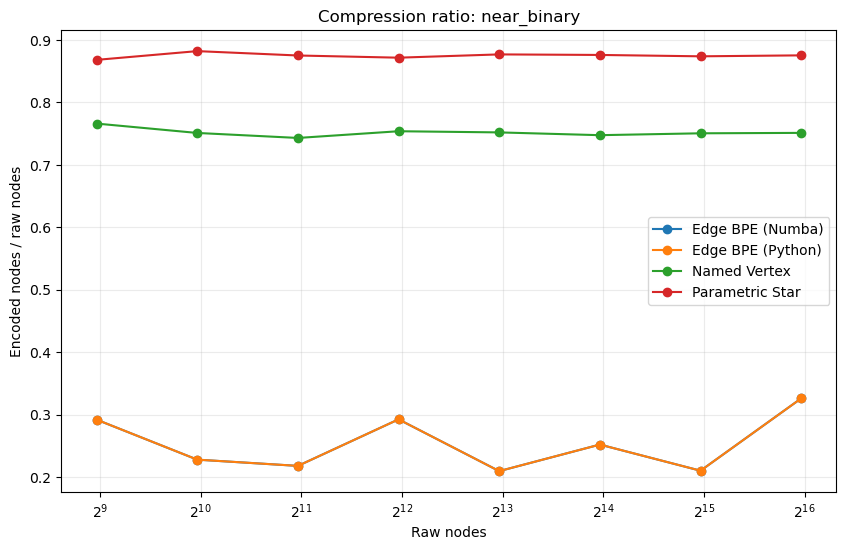

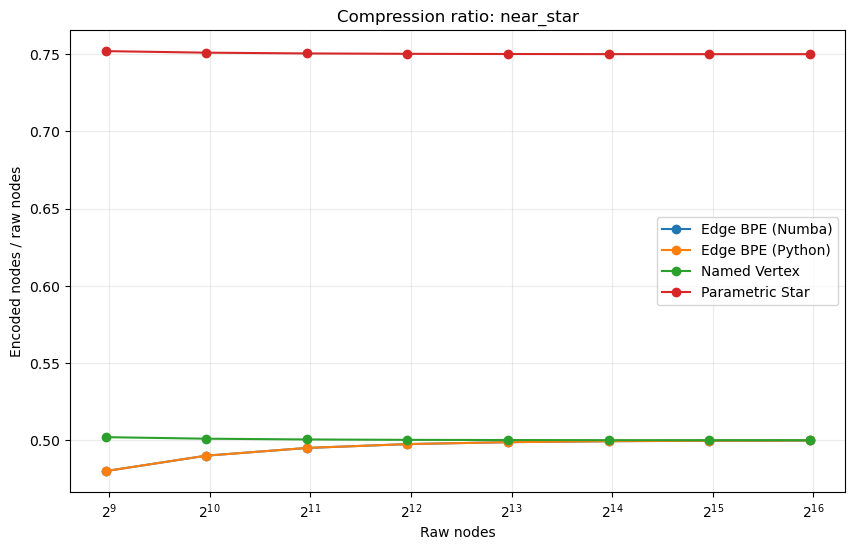

In [8]:
for phase, ylabel in (
    ("fit_median", "Median fit seconds"),
    ("transform_median", "Median transform seconds"),
    ("decode_median", "Median decode seconds"),
):
    for shape in SHAPES:
        figure = plt.figure(figsize=(10, 6))
        axis = figure.gca()
        subset = summary_df[summary_df["shape"] == shape]
        for method_name, group in subset.groupby("method_name", sort=False):
            group = group.sort_values("n_nodes")
            axis.plot(group["n_nodes"], group[phase], marker="o", label=method_name)
        axis.set_xscale("log", base=2)
        axis.set_yscale("log")
        axis.set_xlabel("Raw nodes")
        axis.set_ylabel(ylabel)
        axis.set_title(f"{phase.replace('_median', '').title()} scaling: {shape}")
        axis.grid(True, which="both", alpha=0.25)
        axis.legend()
        plt.show()

for shape in SHAPES:
    figure = plt.figure(figsize=(10, 6))
    axis = figure.gca()
    subset = summary_df[summary_df["shape"] == shape]
    for method_name, group in subset.groupby("method_name", sort=False):
        group = group.sort_values("n_nodes")
        axis.plot(group["n_nodes"], group["compression_ratio"], marker="o", label=method_name)
    axis.set_xscale("log", base=2)
    axis.set_xlabel("Raw nodes")
    axis.set_ylabel("Encoded nodes / raw nodes")
    axis.set_title(f"Compression ratio: {shape}")
    axis.grid(True, which="both", alpha=0.25)
    axis.legend()
    plt.show()

## 8. Save reproducible results

The JSON file records benchmark controls and the execution environment. Keep
both files when comparing commits.


In [9]:
if SAVE_RESULTS:
    output_dir = ROOT / "benchmark_results"
    output_dir.mkdir(exist_ok=True)
    csv_path = output_dir / f"coarsener_scaling_{PROFILE}.csv"
    json_path = output_dir / f"coarsener_scaling_{PROFILE}_metadata.json"
    results_df.to_csv(csv_path, index=False)
    metadata = {
        "environment": ENVIRONMENT,
        "profile": PROFILE,
        "sizes": list(SIZES),
        "repeats": REPEATS,
        "shapes": list(SHAPES),
        "methods": list(METHODS),
        "validate": VALIDATE,
        "bpe_num_merges": BPE_NUM_MERGES,
        "bpe_min_pair_count": BPE_MIN_PAIR_COUNT,
        "numba_cold_warmup_seconds": numba_cold_seconds,
    }
    json_path.write_text(json.dumps(metadata, indent=2, sort_keys=True) + "\n", encoding="utf-8")
    print(csv_path.relative_to(ROOT))
    print(json_path.relative_to(ROOT))

benchmark_results/coarsener_scaling_extended.csv
benchmark_results/coarsener_scaling_extended_metadata.json


## 9. Release interpretation checklist

- Confirm every correctness column is `True`.
- Confirm rule counts and compression ratios remain nontrivial across sizes.
- Compare only like-for-like environments and validation levels.
- Treat the Numba warm-up value as cold-start cost; compare warmed rows to warmed
  rows.
- Investigate sustained slope changes or a repeatable 10–15%+ regression, not a
  single noisy point.
- Repeat the same public-call timings on representative project trees before
  release; these controlled shapes are necessary but not sufficient.
